In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt

In [2]:
from math import pi, sin


g = 9.8
h0 = 1.0
v0 = 13.5
alpha = pi/4

def true_solution(t):
    return h0 + v0*t*sin(alpha) - 0.5*g*t**2
t_min,t_max = 0.0, 2.0
N_data = 10
t_data = torch.linspace(t_min, t_max, N_data)

np.random.seed(0)
noise_level = 0.5
h_data_exact = true_solution(t_data)
h_data_noisy = h_data_exact + noise_level * torch.randn(N_data)


t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)
h_data_tensor = torch.tensor(h_data_noisy, dtype=torch.float32).view(-1, 1)
df = pd.DataFrame({'t': t_data.numpy(), 'h_exp': h_data_noisy.numpy(), 'h_exact': h_data_exact.numpy()})

/tmp/ipykernel_15648/4159753404.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)
/tmp/ipykernel_15648/4159753404.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  h_data_tensor = torch.tensor(h_data_noisy, dtype=torch.float32).view(-1, 1)


In [3]:
df

,t,h_exp,h_exact
0,0.000000,0.802169,1.000000
1,0.222222,3.119566,2.879345
2,0.444444,3.738593,4.274739
3,0.666667,5.709007,5.186183
4,0.888889,5.509659,5.613676
5,1.111111,6.373135,5.557220
6,1.333333,5.927379,5.016809
7,1.555556,5.066531,3.992452
8,1.777778,1.952140,2.484141
9,2.000000,0.544460,0.491882


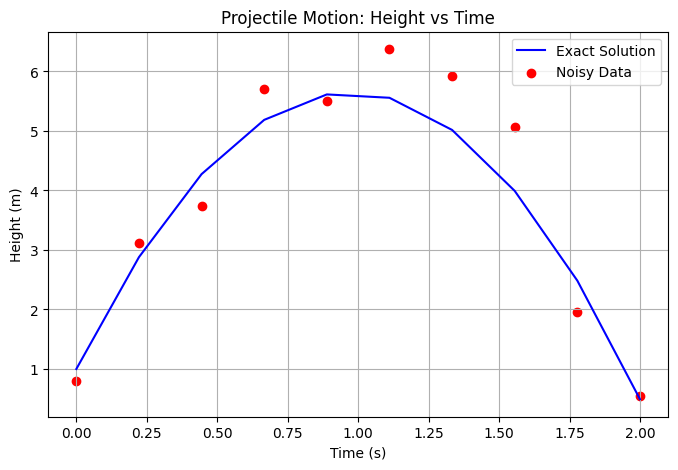

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(t_data, h_data_exact, label='Exact Solution', color='blue')
plt.scatter(t_data, h_data_noisy, label='Noisy Data', color='red', marker='o')
plt.title('Projectile Motion: Height vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.legend()
plt.grid()

In [5]:
class PINN(nn.Module):
    def __init__(self, n_hidden=20):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, t):
        return self.net(t)



In [6]:
def data_loss(model, t_data, h_data):
    h_pred = model(t_data)
    return torch.mean((h_pred - h_data)**2)

In [7]:
def initial_condition_loss(model):
    t0 = torch.zeros((1, 1), dtype=torch.float32, requires_grad=False)
    h0_pred = model(t0)
    return (h0_pred - h0).pow(2).mean()

In [ ]:
def derivative(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]

In [9]:
def physics_loss(model, t_data):
    t_data.requires_grad = True
    h_pred = model(t_data)
    dh_dt_pred = derivative(h_pred, t_data)
    dh_dt_true = v0 * sin(alpha) - g * t_data
    loss_ode = torch.mean((dh_dt_pred - dh_dt_true)**2)
    return loss_ode

In [10]:
lambda_data = 2.0
lambda_ode = 8.0
lambda_ic = 8.0
num_epochs = 8000
print_every = 1000

In [15]:
from torch.optim import optimizer


def train (model, with_pinn = True):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        l_data = data_loss(model, t_data_tensor, h_data_tensor)

        if with_pinn == True:
            l_ic = initial_condition_loss(model)
            l_ode = physics_loss(model, t_data_tensor)
            loss = lambda_data * l_data + lambda_ic * l_ic + lambda_ode * l_ode
        else:
            loss = l_data
        
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Total Loss: {loss.item():.6f},')


In [16]:
model_no_pinn = PINN(n_hidden=30)
model_pinn = PINN(n_hidden=30)

In [18]:

print("\nTraining without PINN:")
train(model_no_pinn, with_pinn = False)
print("\nTraining with PINN:")
train(model_pinn, with_pinn = True)


Training without PINN:
Epoch [1000/8000], Total Loss: 0.000000,
Epoch [2000/8000], Total Loss: 0.000077,
Epoch [3000/8000], Total Loss: 0.000001,
Epoch [4000/8000], Total Loss: 0.000000,
Epoch [5000/8000], Total Loss: 0.000025,
Epoch [6000/8000], Total Loss: 0.000000,
Epoch [7000/8000], Total Loss: 0.000046,
Epoch [8000/8000], Total Loss: 0.000001,

Training with PINN:
Epoch [1000/8000], Total Loss: 0.170796,
Epoch [2000/8000], Total Loss: 0.148581,
Epoch [3000/8000], Total Loss: 0.014658,
Epoch [4000/8000], Total Loss: 0.011284,
Epoch [5000/8000], Total Loss: 0.024122,
Epoch [6000/8000], Total Loss: 0.009481,
Epoch [7000/8000], Total Loss: 0.008784,
Epoch [8000/8000], Total Loss: 0.008247,
